# **Empty Graphs**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# PepProtGraphAnalyzer framework
sys.path.append('/home/jovyan/work/PepProtGraphAnalyzer')
from PepProtGraphAnalyzer.module.notebook import NotebookApp
from PepProtGraphAnalyzer.util.plotting import bar_chart

app = NotebookApp('.env.jupyter.AVPExternal')
paths = app.paths()

[2025-12-09 18:22:25,824] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/out_paper/AVP-external/Log/Sequences with Non-Natural Amino Acids.csv
[2025-12-09 18:22:43,278] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/AVPDiscover/AVP-external.csv
pdb_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/AVPDiscover/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/out_paper/AVP-external
sequence_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/AVPExternal/2025-04-07T19.52.26-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/AVPExternal/2025-04-07T21.26.46-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Empty Graph Data**

In [2]:
data = pd.read_csv(app.graph_analysis['graph_metrics'])
data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)

data['graph_status'] = data['number_of_edges'].apply(lambda x: 'empty graph' if x == 0 else 'non-empty graph')
graph_counts = data[data['graph_status'] == 'empty graph'].groupby('distance_interval').size()

graph_counts = graph_counts.reindex(data['distance_interval'].unique(), fill_value=0)
graph_counts = graph_counts.reset_index(name='Count')
graph_counts.columns = ['distance_interval', 'number_of_empty_graphs']

graph_counts

,distance_interval,number_of_empty_graphs
0,"euclidean (0, 10.2836)",0
1,"euclidean (0, 16.6132)",0
2,"euclidean (0, 26.242)",0
3,"canberra (0, 0.6155)",7
4,"canberra (0, 1.0142)",0
5,"canberra (0, 1.4712)",0
6,"lance_williams (0, 0.1789)",1
7,"lance_williams (0, 0.3041)",0
8,"lance_williams (0, 0.466)",0
9,"clark (0, 0.4161)",6


### **Analysis of the Number of Empty Graphs per Distance Interval**

<br>Number of Empty Graphs

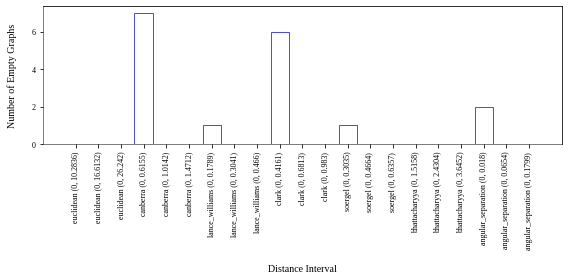

In [3]:
x_label = 'Distance Interval'
y_label = 'Number of Empty Graphs'

display(Markdown("<br>Number of Empty Graphs"))
output = paths['graph_metrics_path'].joinpath("Empty Graphs -histogram ")
plt = bar_chart(graph_counts, 'distance_interval', 'number_of_empty_graphs', x_label=x_label, y_label=y_label, output=output, fig_size=(8, 4), x_ticks_rotation=90)
plt.show()